<a href="https://colab.research.google.com/github/leajag/2025_ML_EES/blob/main/final_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Common imports
import numpy as np
import matplotlib as plt
import pandas as pd
import os
import matplotlib.pyplot as plt

# Extra imports for data pre- processing
!pip install rasterio
import rasterio

!pip install geopandas
import geopandas as gpd

!pip install --upgrade pyshp

!pip install --upgrade shapely

!pip install --upgrade descartes

!pip install --upgrade rtree

from __future__ import print_function

from osgeo import ogr

#for CNN
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from keras.utils import plot_model
from sklearn.model_selection import train_test_split



In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive

'Albedo img'	    GEEDiT_export_LJ.geojson  'notebooks glacier'
'Colab Notebooks'   ML_project		      'RGB img'


In [5]:
data = np.load("/content/drive/MyDrive/ML_project/data_arrays.npz")
X = data['X']
y = data['y']

In [6]:
y_labels = y[:, 0, 0]  # takes left upper pixel per image, to ensure, that all classes are in test set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y_labels
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2880, 3, 128, 128)
X_test shape: (320, 3, 128, 128)
y_train shape: (2880, 128, 128)
y_test shape: (320, 128, 128)


In [7]:
y_train_labels = y_train[:,0,0]  # upper left pixel to adjust labels as for all pixels in one image same class
y_test_labels = y_test[:,0,0]


**k-fold Cross validation:**

In [16]:
from sklearn.model_selection import StratifiedKFold #Generate test sets such that all contain the same distribution of classes, or as close as possible.

# 5-Fold Stratified Cross Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
X_base_train, y_base_train = X_train, y_train # Preserve the original training sets

for fold, (train_index, val_index) in enumerate(kf.split(X_base_train, y_train_labels)):
    #print(f"Fold {fold+1}")

    # Assign to new variables for each fold to avoid modifying the original X_train and y_train
    X_fold_train, X_fold_valid = X_base_train[train_index], X_base_train[val_index]
    y_fold_train, y_fold_valid = y_base_train[train_index], y_base_train[val_index]

    # You would then use X_fold_train, y_fold_train, X_fold_valid, y_fold_valid for your model training and validation within this fold.

In [18]:
print(X_fold_train.shape)
print(y_fold_train.shape)


(2304, 3, 128, 128)
(2304, 128, 128)


In [19]:
#flatten layer for RFC to 2D array
# Flatten X_fold_train from (samples, channels, height, width) to (samples, features)

X_train_2D = X_fold_train.reshape(X_fold_train.shape[0], -1)
y_train_2D = y_fold_train.reshape(y_fold_train.shape[0], -1)

X_test_2D = X_test.reshape(X_test.shape[0], -1)
y_test_2D = y_test.reshape(y_test.shape[0], -1)

print("X train", X_fold_train.shape)
print("y test", y_test.shape)

print( "X train 2D", X_train_2D.shape)
print("X test 2D", X_test_2D.shape)
print("y train 2D", y_train_2D.shape)
print("y test 2D", y_test_2D.shape)




X train (2304, 3, 128, 128)
y test (320, 128, 128)
X train 2D (2304, 49152)
X test 2D (320, 49152)
y train 2D (2304, 16384)
y test 2D (320, 16384)


**Logistic Regression:**

In [89]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(multi_class = "multinomial",max_iter=1000, random_state=42)
clf.fit(X_train_2D, y_train_labels[train_index])


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [91]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf_preds = clf.predict(X_test_2D)
clf_acc = accuracy_score(y_test_labels, clf_preds)
print("CLF accuracy score:", clf_acc)

RF accuracy score: 0.609375


**Random Forest:**

In [80]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

# Use y_train_labels for the current fold
rfc.fit(X_train_2D, y_train_labels[train_index])

RandomForestClassifier()

In [87]:
rfc_preds = rfc.predict(X_test_2D)
rfc_acc = accuracy_score(y_test_labels, rfc_preds)
print("RF accuracy score:", rfc_acc)


RF accuracy score: 0.625


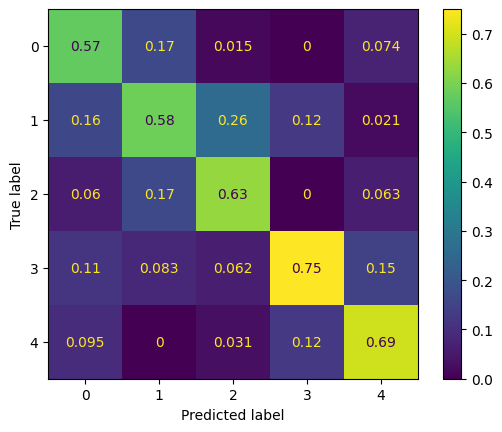

In [86]:
cm = confusion_matrix(y_test_labels, rfc_preds, normalize="pred") # Get a confusion matrix 'cm', use 'pred' for the normalize option
disp = ConfusionMatrixDisplay(confusion_matrix = cm) # Use ConfusionMatrixDisplay to visualize 'cm'
disp.plot()


In [92]:
#RandomizedSearchCV for hyperparameter search -> took too long
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rfc = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(2, 5),
    'max_features': ['sqrt']
}

random_search = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=10,        # 50 zufällige Kombinationen
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train_2D, y_train_labels[train_index])
print("best parameters:",random_search.best_params_)
print("best score:", random_search.best_score_)



Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 

**CNN:**
model1

In [8]:
model1 = tf.keras.Sequential()
# Correct input_img_shape for (height, width, channels)
input_img_shape = (X_train.shape[2], X_train.shape[3], X_train.shape[1])

In [9]:
#layers from 5.2 lab
#first layer: 16 filters, a 3x3 kernel size, a ReLU activation function and 'SAME' padding, weights are initialised by providing the input_shape argument in the first layer.
model1.add(tf.keras.layers.Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'))
model1.add(tf.keras.layers.Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'))
model1.add(MaxPooling2D((8,8),name='pool_1'))
model1.add(tf.keras.layers.Flatten(name='flatten'))
model1.add(tf.keras.layers.Dense(32, activation='relu',name='dense_1'))
model1.add(tf.keras.layers.Dense(10,activation='softmax',name='dense_2'))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 128, 128, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,506 (263.70 KB)

 Trainable params: 67,506 (263.70 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model1.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

In [20]:
print("",y_fold_valid_labels.shape


SyntaxError: incomplete input (ipython-input-4176579441.py, line 1)

In [21]:
# Transpose X_fold_train and X_fold_valid to (batch, height, width, channels)
X_fold_train_transposed = np.transpose(X_fold_train, (0, 2, 3, 1))
X_fold_valid_transposed = np.transpose(X_fold_valid, (0, 2, 3, 1))

# Use image-level labels for y_fold_train and y_fold_valid
y_fold_train_labels = y_train_labels[train_index] # Use training labels for the training set
y_fold_valid_labels = y_train_labels[val_index]   # Use validation labels for the validation set

epochs = 15

history = model1.fit(X_fold_train_transposed, y_fold_train_labels,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(X_fold_valid_transposed, y_fold_valid_labels))

Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.1843 - loss: 16.8143 - val_accuracy: 0.1875 - val_loss: 2.2551
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1852 - loss: 2.2422 - val_accuracy: 0.1875 - val_loss: 2.2008
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1977 - loss: 2.1877 - val_accuracy: 0.1892 - val_loss: 2.1503
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1957 - loss: 2.1387 - val_accuracy: 0.2500 - val_loss: 2.1039
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2517 - loss: 2.0916 - val_accuracy: 0.2500 - val_loss: 2.0615
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2432 - loss: 2.0523 - val_accuracy: 0.2500 - val_loss: 2.0231
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2567 - loss: 2.0141 - val_accuracy: 0.2500 - val_loss: 1.9884
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2359 - loss: 1.9811 - val_accuracy: 0.2500 - 

In [23]:
X_test.shape


(320, 3, 128, 128)

In [24]:
# Transpose X_test to (batch, height, width, channels) for evaluation
X_test_transposed = np.transpose(X_test, (0, 2, 3, 1))

# Use y_test_labels for image-level classification evaluation
score = model1.evaluate(x=X_test_transposed, y=y_test_labels, verbose=0)
print('Test accuracy: {acc:0.3f}'.format(acc=score[1]))

Test accuracy: 0.250


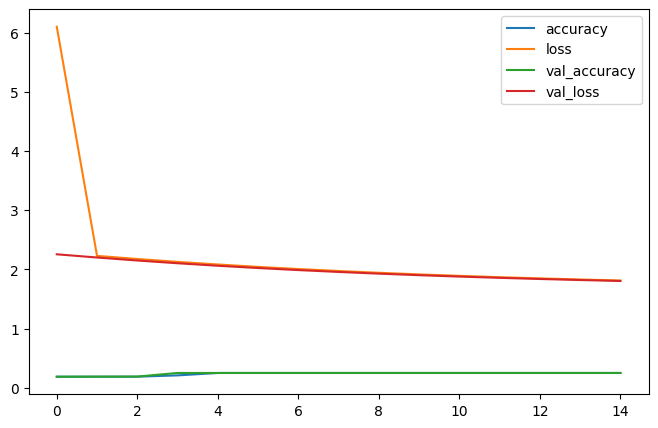

In [25]:
pd.DataFrame(history.history).plot(figsize=(8,5))
plt.show()

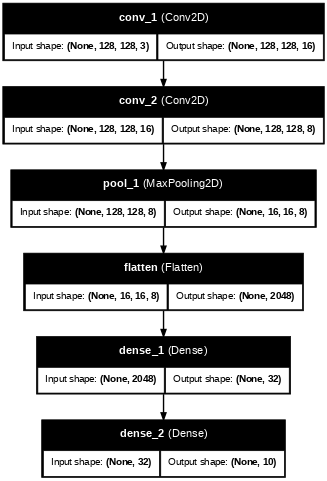

In [26]:
# Plot the model using Keras model plotting utilities
tf.keras.utils.plot_model(model1, show_shapes=True, show_layer_names=True, dpi=50 )

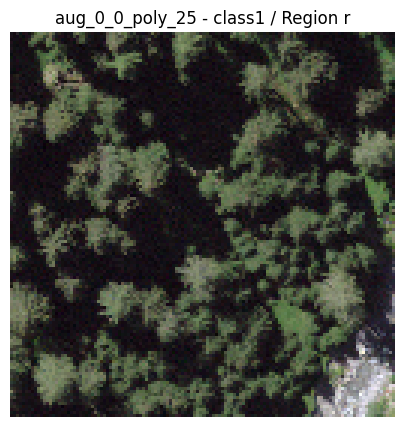

In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Pfad zum Raster
raster_path = "/content/drive/MyDrive/ML_project/data/d/class1/aug_0_1_poly_91.tif"

# Raster laden
with rasterio.open(raster_path) as src:
    img = src.read()  # shape: (4, H, W)
    profile = src.profile

# RGB extrahieren (erste 3 Bänder)
rgb = img[:3, :, :]

# Rasterio liest als (B, H, W) → matplotlib erwartet (H, W, B)
rgb = np.moveaxis(rgb, 0, -1)

# Optional: Werte auf 0-255 strecken, falls Max < 255
for i in range(3):
    band = rgb[:, :, i]
    rgb[:, :, i] = ((band - band.min()) / (band.max() - band.min()) * 255).astype(np.uint8)

# Plot
plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title("aug_0_0_poly_25 - class1 / Region r")
plt.axis('off')
plt.show()


In [11]:
import os
import numpy as np
import rasterio

# Ordner mit allen TIF-Dateien
data_folder = "/content/drive/MyDrive/ML_project/data"

# Listen für X und y
X_list = []
y_list = []

# Alle TIF-Dateien durchgehen
for fname in os.listdir(data_folder):
    if not fname.endswith(".tif"):
        continue

    file_path = os.path.join(data_folder, fname)

    with rasterio.open(file_path) as src:
        # Alle Bänder einlesen
        img = src.read()  # shape = (bands, height, width)

        # X = RGB (Bänder 1,2,3)
        X_rgb = img[0:3, :, :]  # shape = (3, H, W)
        X_list.append(X_rgb)

        # y = Band 4
        y_band4 = img[3, :, :]  # shape = (H, W)
        y_list.append(y_band4)

# In numpy arrays umwandeln
X = np.array(X_list)  # shape = (num_samples, 3, H, W)
y = np.array(y_list)  # shape = (num_samples, H, W)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (3200, 3, 128, 128)
y shape: (3200, 128, 128)


In [17]:
X.shape[3]

128

array([[122, 124, 156, ...,  35,  70,  90],
       [160, 167, 116, ...,  61,  78,  93],
       [166, 119, 104, ...,  79,  72,  98],
       ...,
       [ 91,  74,  20, ...,  15,  37,  78],
       [ 68,  32,   7, ...,  43,  51,  66],
       [ 62,  17,   9, ...,  57,  77,  74]], dtype=uint8)
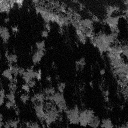

In [20]:
X[1][0]

In [19]:
X[1]

array([[[122, 124, 156, ...,  35,  70,  90],
        [160, 167, 116, ...,  61,  78,  93],
        [166, 119, 104, ...,  79,  72,  98],
        ...,
        [ 91,  74,  20, ...,  15,  37,  78],
        [ 68,  32,   7, ...,  43,  51,  66],
        [ 62,  17,   9, ...,  57,  77,  74]],

       [[137, 137, 159, ...,  48,  90, 101],
        [160, 169, 123, ...,  63,  97, 119],
        [163, 123, 115, ...,  98, 103, 119],
        ...,
        [114,  82,  25, ...,  31,  47,  91],
        [ 90,  44,  11, ...,  69,  63,  75],
        [ 73,  23,  10, ...,  90,  91,  96]],

       [[116, 120, 150, ...,  30,  65,  69],
        [152, 166, 105, ...,  62,  69,  80],
        [158, 109,  98, ...,  66,  72,  76],
        ...,
        [ 86,  59,  21, ...,  30,  36,  65],
        [ 67,  30,  10, ...,  44,  41,  56],
        [ 56,  21,  12, ...,  59,  58,  57]]], dtype=uint8)

In [24]:
np.savez("/content/drive/MyDrive/ML_project/data_arrays.npz", X=X, y=y)


In [26]:
data = np.load("/content/drive/MyDrive/ML_project/data_arrays.npz")
X = data['X']
y = data['y']